# Deng on-road EV charging-data loader verification

This notebook checks the Deng loader against the 20 held charging-data archives. It uses the public loader, measures pack coverage and charge sessions, and keeps interpretation tied to displayed outputs.

## 1. File inventory

This step calls `systems()` and then loads each pack once. Check that 20 archives are represented and that the files are non-empty.

In [1]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'fielddata').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from fielddata import load, systems
from fielddata.registry import PACKAGES

packs = systems('deng')
profiles = []
sessions_all = []
for pack in packs['pack']:
    frame = load('deng', pack=pack)
    diffs = frame.index.to_series().sort_values().diff().dt.total_seconds().dropna()
    profiles.append({
        'pack': pack,
        'rows': len(frame),
        'first': frame.index.min(),
        'last': frame.index.max(),
        'median_cadence_s': diffs.median(),
        'soc_min': frame['soc'].min(),
        'soc_max': frame['soc'].max(),
        'available_capacity_median_Ah': frame['available_capacity'].median(),
    })
    ordered = frame.sort_index().reset_index()
    gaps = ordered['record_time'].diff().dt.total_seconds().fillna(0)
    groups = (gaps > 10).cumsum()
    for _, group in ordered.groupby(groups):
        if len(group) < 100:
            continue
        soc = group['soc'].astype(float).to_numpy()
        swing = soc[-1] - soc[0]
        if swing <= 30:
            continue
        seconds = (group['record_time'] - group['record_time'].iloc[0]).dt.total_seconds().to_numpy()
        current = group['charge_current'].astype(float).to_numpy()
        charge_ah = -np.trapezoid(current, seconds) / 3600
        if not np.isfinite(charge_ah) or charge_ah <= 0:
            continue
        measured_ah = charge_ah / (swing / 100)
        bms_ah = group['available_capacity'].astype(float).median()
        sessions_all.append({'pack': pack, 'end_time': group['record_time'].iloc[-1], 'rows': len(group), 'soc_start': soc[0], 'soc_end': soc[-1], 'soc_swing_pct': swing, 'charge_ah': charge_ah, 'measured_capacity_Ah': measured_ah, 'bms_capacity_Ah': bms_ah})
    del frame
profile = pd.DataFrame(profiles)
sessions = pd.DataFrame(sessions_all)
print('packs=' + str(len(profile)))
print('rows=' + str(int(profile['rows'].sum())))
print('sessions_soc_swing_gt_30=' + str(len(sessions)))

display(packs[['pack','archive','bytes','vehicle_model','series_cells','nominal_capacity_Ah']])
display(profile[['pack','rows','first','last']])

packs=20
rows=16100728
sessions_soc_swing_gt_30=13877


,pack,archive,bytes,vehicle_model,series_cells,nominal_capacity_Ah
0,#1,#1.rar,12238871,BAIC EU500,90,145
1,#2,#2.rar,12088035,BAIC EU500,90,145
2,#3,#3.rar,11451253,BAIC EU500,90,145
3,#4,#4.rar,12084749,BAIC EU500,90,145
4,#5,#5.rar,11888317,BAIC EU500,90,145
5,#6,#6.rar,11663814,BAIC EU500,90,145
6,#7,#7.rar,11606222,BAIC EU500,90,145
7,#8,#8.rar,11507641,BAIC EU500,90,145
8,#9,#9.rar,11232824,BAIC EU500,90,145
9,#10,#10.rar,10508142,BAIC EU500,90,145


,pack,rows,first,last
0,#1,854591,2019-07-26 20:02:35,2021-11-15 16:46:40
1,#2,841810,2019-07-25 15:14:26,2021-11-15 14:12:56
2,#3,802918,2019-07-26 19:08:05,2021-11-15 22:20:40
3,#4,844537,2019-07-25 15:58:38,2021-11-15 17:57:51
4,#5,832189,2019-07-26 00:22:51,2021-11-15 17:44:04
5,#6,815202,2019-07-25 18:35:34,2021-11-15 15:59:52
6,#7,808770,2019-07-26 09:00:02,2021-11-15 15:54:48
7,#8,798496,2019-07-26 10:26:45,2021-11-15 21:01:06
8,#9,792060,2019-07-23 21:27:55,2021-11-15 19:19:13
9,#10,728849,2019-07-24 23:00:08,2021-11-15 14:07:37


The output shows 20 pack archives and 16,100,728 total rows. The displayed profile gives the first and last timestamp for each pack.

## 2. Table shape

This step checks the columns returned by the loader for one pack. The same names are used by the session calculation.

In [2]:

example = load('deng', pack='#1')
display(pd.DataFrame({'column': example.reset_index().columns, 'dtype': [str(t) for t in example.reset_index().dtypes]}))
print('columns=' + str(example.reset_index().shape[1]))


,column,dtype
0,record_time,datetime64[us]
1,number,int64
2,soc,float64
3,pack_voltage,float64
4,charge_current,float64
5,max_cell_voltage,float64
6,min_cell_voltage,float64
7,max_temperature,int64
8,min_temperature,int64
9,available_energy,float64


columns=12


The output shows 12 columns after `load()` adds the pack identifier and sets `record_time` as the index. The key columns for charge capacity are `record_time`, `charge_current`, and `soc`.

## 3. Time axis

This step reports the measured span and median cadence for each pack. Check whether the records cover roughly the same period.

In [3]:

display(profile[['pack','first','last','median_cadence_s']])
print('overall_first=' + str(profile['first'].min()))
print('overall_last=' + str(profile['last'].max()))


,pack,first,last,median_cadence_s
0,#1,2019-07-26 20:02:35,2021-11-15 16:46:40,8.0
1,#2,2019-07-25 15:14:26,2021-11-15 14:12:56,8.0
2,#3,2019-07-26 19:08:05,2021-11-15 22:20:40,8.0
3,#4,2019-07-25 15:58:38,2021-11-15 17:57:51,8.0
4,#5,2019-07-26 00:22:51,2021-11-15 17:44:04,8.0
5,#6,2019-07-25 18:35:34,2021-11-15 15:59:52,8.0
6,#7,2019-07-26 09:00:02,2021-11-15 15:54:48,10.0
7,#8,2019-07-26 10:26:45,2021-11-15 21:01:06,8.0
8,#9,2019-07-23 21:27:55,2021-11-15 19:19:13,10.0
9,#10,2019-07-24 23:00:08,2021-11-15 14:07:37,8.0


overall_first=2019-07-22 16:35:17
overall_last=2021-11-16 01:05:42


The output shows pack spans from late July 2019 to mid November 2021. Median cadence is 8 seconds for most packs and 10 seconds for the remaining packs.

## 4. Per-unit table

This step displays one row per monitored vehicle pack. It is the table returned by `systems()`.

In [4]:

display(packs)
print('systems_rows=' + str(len(packs)))


,pack,unit,archive,bytes,chemistry,vehicle_model,series_cells,nominal_capacity_Ah
0,#1,#1,#1.rar,12238871,NCM,BAIC EU500,90,145
1,#2,#2,#2.rar,12088035,NCM,BAIC EU500,90,145
2,#3,#3,#3.rar,11451253,NCM,BAIC EU500,90,145
3,#4,#4,#4.rar,12084749,NCM,BAIC EU500,90,145
4,#5,#5,#5.rar,11888317,NCM,BAIC EU500,90,145
5,#6,#6,#6.rar,11663814,NCM,BAIC EU500,90,145
6,#7,#7,#7.rar,11606222,NCM,BAIC EU500,90,145
7,#8,#8,#8.rar,11507641,NCM,BAIC EU500,90,145
8,#9,#9,#9.rar,11232824,NCM,BAIC EU500,90,145
9,#10,#10,#10.rar,10508142,NCM,BAIC EU500,90,145


systems_rows=20


The output shows 20 monitored packs. Each row identifies the archive, chemistry, vehicle model, series cell count, and nominal capacity.

## 5. Signal envelopes

This step plots daily medians for one example pack and summarizes signal ranges over all packs. The example is pack #1 because it is the first archive in sorted order.

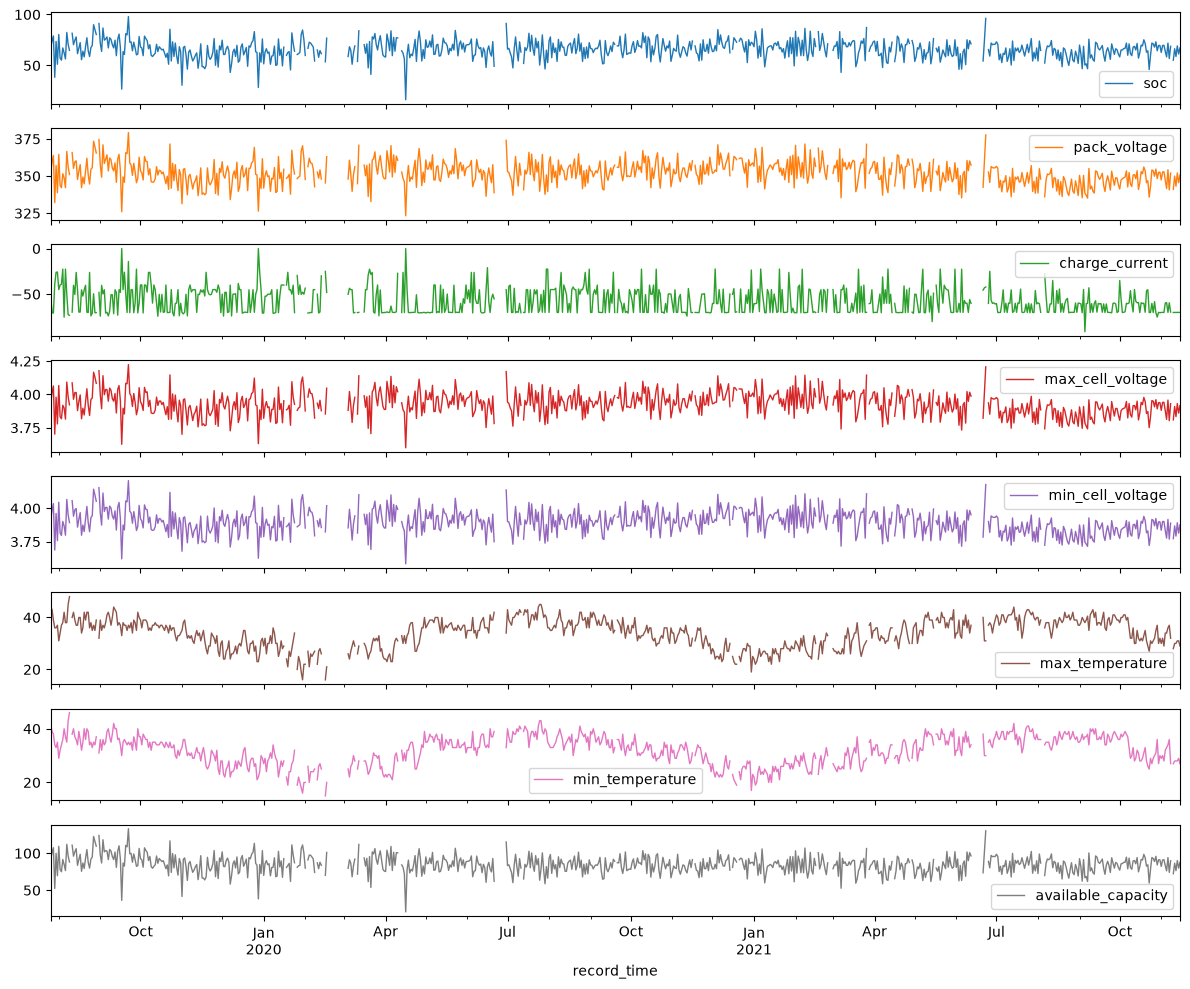

,pack,soc_min,soc_max,current_min_A,current_max_A,capacity_median_Ah
0,#1,1.2,100.0,-93.20001,0.000000,85.04000
1,#2,0.4,100.0,-92.70001,11.299990,85.48000
2,#3,0.8,100.0,-89.50000,7.699982,85.43000
3,#4,0.0,100.0,-95.10001,12.000000,85.56000
4,#5,0.0,100.0,-94.70001,10.299990,84.88000
5,#6,0.8,100.0,-400.02000,0.000000,86.29000
6,#7,1.2,100.0,-94.70001,0.000000,85.97000
7,#8,0.8,100.0,-93.60001,12.000000,85.78000
8,#9,0.0,100.0,-91.60001,0.000000,85.48000
9,#10,0.0,100.0,-81.50000,11.599980,87.61000


In [5]:

example_daily = example[['soc','pack_voltage','charge_current','max_cell_voltage','min_cell_voltage','max_temperature','min_temperature','available_capacity']].resample('D').median()
axes = example_daily.plot(subplots=True, figsize=(12, 10), sharex=True, linewidth=1)
plt.tight_layout()
plt.show()
range_rows = []
for pack in packs['pack']:
    frame = load('deng', pack=pack)
    range_rows.append({'pack': pack, 'soc_min': frame['soc'].min(), 'soc_max': frame['soc'].max(), 'current_min_A': frame['charge_current'].min(), 'current_max_A': frame['charge_current'].max(), 'capacity_median_Ah': frame['available_capacity'].median()})
range_table = pd.DataFrame(range_rows)
display(range_table)


The output shows pack #1 daily median signal envelopes and a range table for all 20 packs. The range table includes SOC limits, current limits, and median `available_capacity`, the BMS remaining charge in Ah, which rises with SOC.

## 6. Sanity ranges

This step checks broad physical ranges for SOC, voltage, current, and temperature. Nonzero counts point to rows that need caution.

In [6]:

checks = []
for pack in packs['pack']:
    frame = load('deng', pack=pack)
    checks.append({'pack': pack, 'soc_outside_0_100': int(((frame['soc'] < 0) | (frame['soc'] > 100)).sum()), 'pack_voltage_outside_200_500': int(((frame['pack_voltage'] < 200) | (frame['pack_voltage'] > 500)).sum()), 'positive_charge_current_rows': int((frame['charge_current'] > 0).sum()), 'temperature_outside_minus40_80': int(((frame['max_temperature'] < -40) | (frame['max_temperature'] > 80) | (frame['min_temperature'] < -40) | (frame['min_temperature'] > 80)).sum())})
sanity = pd.DataFrame(checks)
display(sanity)


,pack,soc_outside_0_100,pack_voltage_outside_200_500,positive_charge_current_rows,temperature_outside_minus40_80
0,#1,0,0,0,0
1,#2,0,0,3,0
2,#3,0,0,2,0
3,#4,0,0,2,0
4,#5,0,0,1,0
5,#6,0,0,0,0
6,#7,0,0,0,0
7,#8,0,0,3,0
8,#9,0,0,0,0
9,#10,0,0,3,0


The output shows broad range-check counts for each pack. The `positive_charge_current_rows` column checks the release sign convention during charging records.

## 7. Sensor cross-consistency

This step compares max and min cell voltage and temperature columns. The check should show nonnegative spreads when the max and min labels are internally consistent.

In [7]:

spread_rows = []
for pack in packs['pack']:
    frame = load('deng', pack=pack)
    spread_rows.append({'pack': pack, 'negative_voltage_spread_rows': int((frame['max_cell_voltage'] < frame['min_cell_voltage']).sum()), 'median_voltage_spread_V': float((frame['max_cell_voltage'] - frame['min_cell_voltage']).median()), 'negative_temperature_spread_rows': int((frame['max_temperature'] < frame['min_temperature']).sum()), 'median_temperature_spread_C': float((frame['max_temperature'] - frame['min_temperature']).median())})
spread_table = pd.DataFrame(spread_rows)
display(spread_table)


,pack,negative_voltage_spread_rows,median_voltage_spread_V,negative_temperature_spread_rows,median_temperature_spread_C
0,#1,0,0.030,0,2.0
1,#2,0,0.034,0,2.0
2,#3,0,0.028,0,2.0
3,#4,0,0.033,0,2.0
4,#5,0,0.031,0,2.0
5,#6,0,0.034,0,2.0
6,#7,0,0.030,0,2.0
7,#8,0,0.024,0,2.0
8,#9,0,0.031,0,2.0
9,#10,0,0.035,0,2.0


The output shows whether any rows reverse the max and min fields. The median spreads describe the typical within-pack spread in voltage and temperature.

## 8. Event segmentation

This step segments charging sessions by gaps longer than 10 seconds and keeps sessions with SOC swing above 30 percentage points. These are the sessions used for coulomb-counted capacity.

In [8]:

summary = sessions.groupby('pack').agg(sessions=('measured_capacity_Ah','size'), median_soc_swing_pct=('soc_swing_pct','median'), median_measured_capacity_Ah=('measured_capacity_Ah','median'), median_bms_capacity_Ah=('bms_capacity_Ah','median')).reset_index()
display(summary)
print('accepted_sessions=' + str(len(sessions)))


,pack,sessions,median_soc_swing_pct,median_measured_capacity_Ah,median_bms_capacity_Ah
0,#1,743,58.0,126.572736,84.205000
1,#10,630,58.6,127.743009,87.010000
2,#11,638,57.4,127.661979,85.635000
3,#12,704,58.0,128.433744,84.617500
4,#13,634,56.4,128.533212,86.957500
5,#14,683,56.8,125.912483,83.300000
6,#15,611,56.8,126.620939,85.080000
7,#16,730,54.4,123.641763,83.752500
8,#17,670,55.6,127.087024,85.635000
9,#18,770,55.2,123.515108,83.855000


accepted_sessions=13877


The output shows the count of accepted high-SOC-swing charging sessions per pack. It also shows median measured capacity and the median BMS remaining charge (`available_capacity`) for those sessions, which is not a capacity estimate.

## 9. Monthly capacity KPI

This step aggregates accepted session capacity by month and pack. It shows coulomb-counted session capacity. The BMS `available_capacity` field is remaining charge, not a capacity, so it is not a comparison for it.

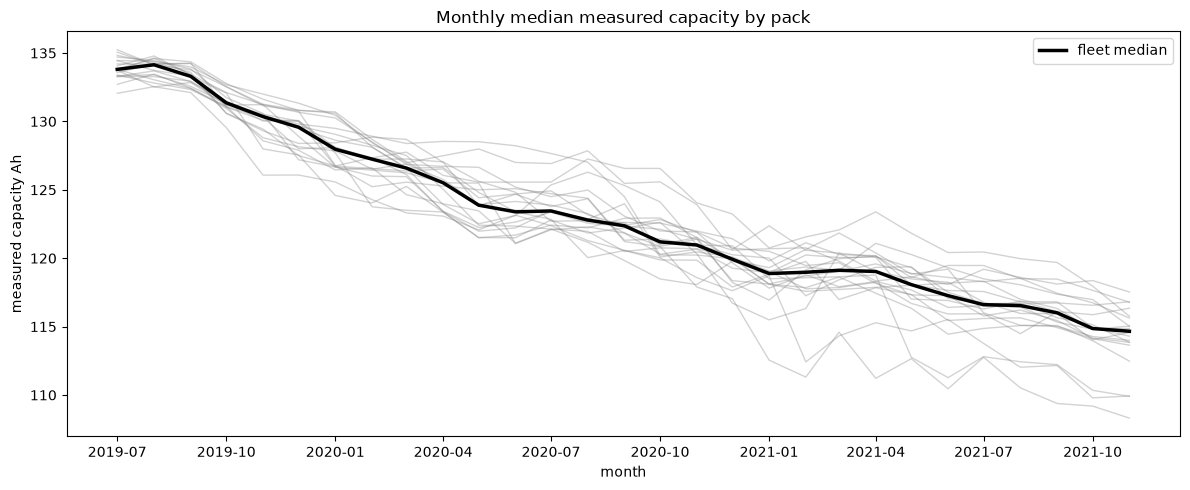

,pack,month,measured_capacity_Ah,bms_capacity_Ah,sessions
0,#1,2019-07-01 00:00:00+00:00,133.735095,92.115000,9
1,#1,2019-08-01 00:00:00+00:00,134.599706,93.089995,45
2,#1,2019-09-01 00:00:00+00:00,134.358579,95.502498,52
3,#1,2019-10-01 00:00:00+00:00,132.769669,90.690000,63
4,#1,2019-11-01 00:00:00+00:00,131.621440,82.547500,54
5,#1,2019-12-01 00:00:00+00:00,130.795778,86.650000,57
6,#1,2020-01-01 00:00:00+00:00,130.697890,84.530000,48
7,#1,2020-02-01 00:00:00+00:00,128.688634,88.687498,16
8,#1,2020-03-01 00:00:00+00:00,127.066526,88.512500,34
9,#1,2020-04-01 00:00:00+00:00,125.515553,84.305000,36


monthly_rows=570


In [9]:

sessions['month'] = sessions['end_time'].dt.to_period('M').dt.to_timestamp().dt.tz_localize('UTC')
monthly = sessions.groupby(['pack','month']).agg(measured_capacity_Ah=('measured_capacity_Ah','median'), bms_capacity_Ah=('bms_capacity_Ah','median'), sessions=('measured_capacity_Ah','size')).reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for pack, group in monthly.groupby('pack'):
    ax.plot(group['month'], group['measured_capacity_Ah'], color='gray', alpha=0.35, linewidth=1)
fleet = monthly.groupby('month')['measured_capacity_Ah'].median().reset_index()
ax.plot(fleet['month'], fleet['measured_capacity_Ah'], color='black', linewidth=2.5, label='fleet median')
ax.set_ylabel('measured capacity Ah')
ax.set_xlabel('month')
ax.set_title('Monthly median measured capacity by pack')
ax.legend()
plt.tight_layout()
plt.show()
display(monthly.head(20))
print('monthly_rows=' + str(len(monthly)))


The output shows monthly median measured capacity by pack with the fleet median in black. The table shows the first 20 monthly pack rows and includes the median BMS remaining charge (`available_capacity`), which is not a capacity.

## 10. Paper cross-check table

This step compares release and paper description values with values measured by the loader. Null means the value was not measured from the released files in this notebook.

In [10]:

cross = pd.DataFrame([
    {'item': 'vehicle packs', 'paper_or_release_value': 20, 'measured_value': len(profile), 'source': 'repository README and archive count'},
    {'item': 'series cells', 'paper_or_release_value': 90, 'measured_value': int(packs['series_cells'].iloc[0]), 'source': 'repository README and systems table'},
    {'item': 'nominal capacity Ah', 'paper_or_release_value': 145, 'measured_value': int(packs['nominal_capacity_Ah'].iloc[0]), 'source': 'repository README and systems table'},
    {'item': 'total rows', 'paper_or_release_value': np.nan, 'measured_value': int(profile['rows'].sum()), 'source': 'measured from all held archives'},
    {'item': 'BMS remaining charge column', 'paper_or_release_value': np.nan, 'measured_value': np.nan, 'source': 'available_capacity column in each CSV'},
])
display(cross)


,item,paper_or_release_value,measured_value,source
0,vehicle packs,20.0,20.0,repository README and archive count
1,series cells,90.0,90.0,repository README and systems table
2,nominal capacity Ah,145.0,145.0,repository README and systems table
3,total rows,NaN,16100728.0,measured from all held archives
4,BMS remaining charge column,NaN,NaN,available_capacity column in each CSV


The output shows 20 measured packs, 90 series cells, and 145 Ah nominal capacity. `available_capacity` is remaining charge, not a capacity estimate (source audit 2026-10-04).